# Stanford bunny data preparation

normalize, repair, slice, voxelize, save one reproducible benchmark. Adapted from https://github.com/haimsaw/OReX/blob/main/Slicer.py.

In [1]:
%pip install -q numpy scipy matplotlib trimesh rtree shapely scikit-image gpytoolbox meshcut

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from collections import Counter
from pathlib import Path

import gpytoolbox as gpy
import matplotlib.pyplot as plt
import numpy as np
import trimesh
from matplotlib.path import Path as MplPath
from meshcut import cross_section

SEED = 7 # to randomize planes
GRID_SIZE = 64 # 64^3
N_SLICES = 6
GRID_MIN, GRID_MAX = -1.0, 1.0
MODEL_DIR = Path("models")
SOURCE = MODEL_DIR / "bunny.obj"
OUTPUT = Path("data/bunny_cross_sections.npz")

rng = np.random.default_rng(SEED)

## Load, repair, and normalize

In [3]:
def boundary_loops(faces):
    directed = np.vstack((faces[:, [0, 1]], faces[:, [1, 2]], faces[:, [2, 0]]))
    counts = Counter(map(tuple, np.sort(directed, axis=1)))
    boundary = [tuple(edge) for edge in directed if counts[tuple(sorted(edge))] == 1]
    outgoing = {}
    for start, end in boundary:
        if start in outgoing:
            raise ValueError("Non-manifold boundary")
        outgoing[start] = end
    loops = []
    while outgoing:
        start = next(iter(outgoing))
        loop = [start]
        current = start
        while current in outgoing:
            current = outgoing.pop(current)
            if current == start:
                break
            loop.append(current)
        if current != start:
            raise ValueError("Open boundary")
        loops.append(np.asarray(loop, dtype=np.int64))
    return loops


def close_mesh(mesh):
    if mesh.is_watertight:
        return mesh.copy(), []
    loops = boundary_loops(mesh.faces)
    vertices = mesh.vertices.tolist()
    faces = mesh.faces.tolist()
    for loop in loops:
        center = len(vertices)
        vertices.append(mesh.vertices[loop].mean(axis=0))
        for i, start in enumerate(loop):
            faces.append([loop[(i + 1) % len(loop)], start, center])
    repaired = trimesh.Trimesh(np.asarray(vertices), np.asarray(faces), process=True)
    if not repaired.is_watertight:
        raise ValueError("Mesh repair did not produce a watertight surface")
    return repaired, loops


mesh = trimesh.load(SOURCE, force="mesh", process=True)
mesh, repaired_loops = close_mesh(mesh)
mesh.apply_translation(-mesh.bounds.mean(axis=0))
mesh.apply_scale(1.8 / np.ptp(mesh.vertices, axis=0).max())

print({
    "vertices": len(mesh.vertices),
    "faces": len(mesh.faces),
    "repaired_boundaries": [len(loop) for loop in repaired_loops],
    "watertight": mesh.is_watertight,
    "bounds": mesh.bounds.round(3).tolist(),
})

{'vertices': 2507, 'faces': 5010, 'repaired_boundaries': [12, 11, 8, 11], 'watertight': True, 'bounds': [[-0.9, -0.891, -0.698], [0.9, 0.891, 0.698]]}


## Ground-truth 3D SDF

In [4]:
axis = np.linspace(GRID_MIN, GRID_MAX, GRID_SIZE)
grid = np.stack(np.meshgrid(axis, axis, axis, indexing="ij"), axis=-1)
points = grid.reshape(-1, 3) # flatten to list of query points

sdf3d, _, _ = gpy.signed_distance(points, mesh.vertices, mesh.faces)
sdf3d = sdf3d.reshape((GRID_SIZE,) * 3).astype(np.float32)
inside = sdf3d < 0

print({"shape": sdf3d.shape, "inside_voxels": int(inside.sum()), "range": [float(sdf3d.min()), float(sdf3d.max())]})

{'shape': (64, 64, 64), 'inside_voxels': 36581, 'range': [-0.4651715159416199, 1.2066959142684937]}


## Random cross-sections and 2D SDFs

In [5]:
def plane_frame(normal):
    reference = np.eye(3)[np.argmin(np.abs(normal))]
    u = np.cross(normal, reference)
    u /= np.linalg.norm(u)
    v = np.cross(normal, u)
    return np.column_stack((u, v))


def sample_sections(mesh, count, rng): # samples random unit normal of given plane and intersects with mesh w/ meshcut
    sections = []
    attempts = 0
    while len(sections) < count and attempts < 100:
        attempts += 1
        normal = rng.normal(size=3)
        normal /= np.linalg.norm(normal)
        projection = mesh.vertices @ normal
        position = rng.uniform(np.quantile(projection, 0.15), np.quantile(projection, 0.85))
        origin = normal * position
        loops = cross_section(mesh.vertices, mesh.faces, origin, normal)
        loops = [np.asarray(loop) for loop in loops if len(loop) >= 3]
        if not loops:
            continue
        loops = [loop if np.allclose(loop[0], loop[-1]) else np.vstack((loop, loop[0])) for loop in loops]
        sections.append({"normal": normal, "offset": -position, "origin": origin, "loops": loops})
    if len(sections) != count:
        raise RuntimeError("Could not sample enough non-empty sections")
    return sections


def signed_in_plane_distance(query, section):
    frame = plane_frame(section["normal"])
    query2d = (query - section["origin"]) @ frame
    distance = np.full(len(query), np.inf)
    inside2d = np.zeros(len(query), dtype=bool)
    for loop3d in section["loops"]:
        loop2d = (loop3d[:-1] - section["origin"]) @ frame
        loop_distance, _, _ = gpy.signed_distance(query2d, loop2d)
        distance = np.minimum(distance, np.abs(loop_distance))
        closed = np.vstack((loop2d, loop2d[0]))
        inside2d ^= MplPath(closed).contains_points(query2d)
    return np.where(inside2d, -distance, distance)


sections = sample_sections(mesh, N_SLICES, rng)
plane_normals = np.stack([section["normal"] for section in sections])
plane_offsets = np.asarray([section["offset"] for section in sections])
plane_origins = np.stack([section["origin"] for section in sections])

sdf2d_flat = np.stack([signed_in_plane_distance(points, section) for section in sections]).astype(np.float32)
plane_distance_flat = points @ plane_normals.T + plane_offsets
plane_distance_flat = plane_distance_flat.T.astype(np.float32)
voxel_width = (GRID_MAX - GRID_MIN) / (GRID_SIZE - 1)
slice_mask_flat = np.abs(plane_distance_flat) <= 0.5 * voxel_width

nearest = np.argmin(np.abs(plane_distance_flat), axis=0)
column = np.arange(len(points))
observed_flat = slice_mask_flat.any(axis=0)
observed_sdf2d_flat = np.where(observed_flat, sdf2d_flat[nearest, column], 0.0)
observed_normal_flat = plane_normals[nearest].T * observed_flat

contour_vertices = []
contour_edges = []
contour_plane = []
for plane_id, section in enumerate(sections):
    for loop in section["loops"]:
        loop = loop[:-1]
        start = len(contour_vertices)
        contour_vertices.extend(loop)
        contour_edges.extend([[start + i, start + (i + 1) % len(loop)] for i in range(len(loop))])
        contour_plane.extend([plane_id] * len(loop))

contour_vertices = np.asarray(contour_vertices)
contour_edges = np.asarray(contour_edges, dtype=np.int32)
contour_plane = np.asarray(contour_plane, dtype=np.int16)
distance_squared, _, _ = gpy.squared_distance(points, contour_vertices, contour_edges, use_cpp=True)
u_obs = np.sqrt(np.maximum(distance_squared, 0.0)).reshape((GRID_SIZE,) * 3).astype(np.float32)

sdf2d = sdf2d_flat.reshape((N_SLICES,) + (GRID_SIZE,) * 3)
plane_distance = plane_distance_flat.reshape((N_SLICES,) + (GRID_SIZE,) * 3)
slice_mask = slice_mask_flat.reshape((N_SLICES,) + (GRID_SIZE,) * 3)
observed_mask = observed_flat.reshape((GRID_SIZE,) * 3)
observed_sdf2d = observed_sdf2d_flat.reshape((GRID_SIZE,) * 3).astype(np.float32)
observed_normal = observed_normal_flat.reshape((3,) + (GRID_SIZE,) * 3).astype(np.float32)

## Save benchmark

In [6]:
OUTPUT.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    OUTPUT,
    seed=np.int64(SEED),
    grid_axis=axis.astype(np.float32),
    vertices=mesh.vertices.astype(np.float32),
    faces=mesh.faces.astype(np.int32),
    sdf3d=sdf3d,
    inside=inside,
    plane_normals=plane_normals.astype(np.float32),
    plane_offsets=plane_offsets.astype(np.float32),
    plane_origins=plane_origins.astype(np.float32),
    plane_distance=plane_distance,
    slice_mask=slice_mask,
    sdf2d=sdf2d,
    observed_mask=observed_mask,
    observed_sdf2d=observed_sdf2d,
    observed_normal=observed_normal,
    u_obs=u_obs,
    contour_vertices=contour_vertices.astype(np.float32),
    contour_edges=contour_edges,
    contour_plane=contour_plane,
)

print(f"{OUTPUT} ({OUTPUT.stat().st_size / 2**20:.1f} MiB)")

data\bunny_cross_sections.npz (13.1 MiB)


## Checks

In [7]:
sample_ids = rng.choice(len(points), size=5000, replace=False)
max_plane_violation = 0.0
for plane_id, section in enumerate(sections):
    projected = points[sample_ids] - plane_distance_flat[plane_id, sample_ids, None] * section["normal"]
    projected_sdf, _, _ = gpy.signed_distance(projected, mesh.vertices, mesh.faces)
    violation = np.abs(projected_sdf) - np.abs(sdf2d_flat[plane_id, sample_ids])
    max_plane_violation = max(max_plane_violation, float(violation.max()))

assert mesh.is_watertight
assert slice_mask_flat.any(axis=1).all()
assert max_plane_violation < 1e-4

print({
    "slices": N_SLICES,
    "loops_per_slice": [len(section["loops"]) for section in sections],
    "observed_voxels": int(observed_mask.sum()),
    "max_sampled_bound_violation": max_plane_violation,
})

{'slices': 6, 'loops_per_slice': [1, 1, 1, 1, 2, 1], 'observed_voxels': 24973, 'max_sampled_bound_violation': 1.333284121995959e-09}


### Analytical 2D section tests

These tests isolate the `meshcut` $\rightarrow$ plane-frame $(u,v)$ $\rightarrow$ `gpytoolbox` 2D-distance pipeline. For the central sections,

$$
\phi_{\mathrm{circle}}(u,v)=\sqrt{u^2+v^2}-r,
$$

and the central torus section is an annulus with

$$
\phi_{\mathrm{torus}\cap z=0}(u,v)=\left|\sqrt{u^2+v^2}-R\right|-r.
$$

The small nonzero error is the expected difference between an exact curved surface and its polygonal mesh.

sphere   loops=1  mean=4.161e-04  p95=7.029e-04  max=7.396e-04  sign=0.99945
cylinder loops=1  mean=2.220e-05  p95=3.759e-05  max=3.765e-05  sign=1.00000
torus    loops=2  mean=8.122e-05  p95=1.495e-04  max=1.504e-04  sign=0.99980


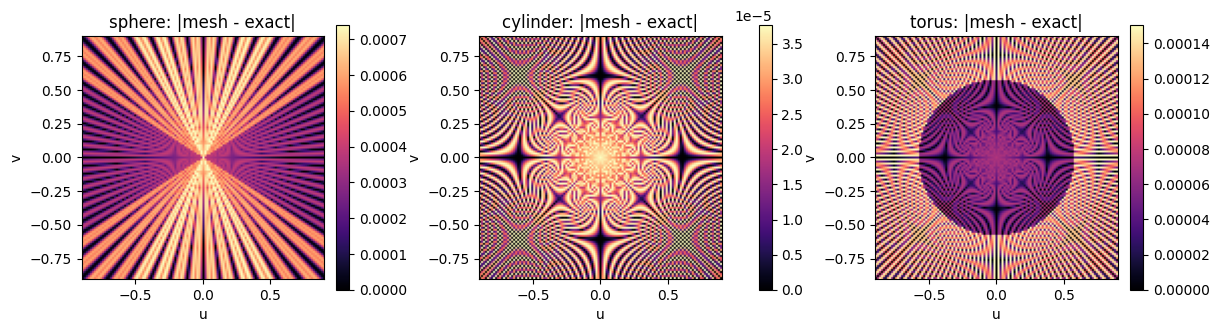

In [8]:
def central_section(mesh):
    normal = np.array([0.0, 0.0, 1.0])
    origin = np.zeros(3)
    loops = cross_section(mesh.vertices, mesh.faces, origin, normal)
    loops = [np.asarray(loop) for loop in loops if len(loop) >= 3]
    loops = [loop if np.allclose(loop[0], loop[-1]) else np.vstack((loop, loop[0])) for loop in loops]
    return {"normal": normal, "origin": origin, "loops": loops}


section_axis = np.linspace(-0.9, 0.9, 121)
section_uv = np.stack(np.meshgrid(section_axis, section_axis, indexing="xy"), axis=-1)
section_models = {
    "sphere": (lambda uv: np.linalg.norm(uv, axis=1) - 0.65, 0.002),
    "cylinder": (lambda uv: np.linalg.norm(uv, axis=1) - 0.50, 0.0002),
    "torus": (lambda uv: np.abs(np.linalg.norm(uv, axis=1) - 0.58) - 0.20, 0.0005),
}

section_results = []
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
for ax, (name, (exact_sdf, tolerance)) in zip(axes, section_models.items()):
    test_mesh = trimesh.load(MODEL_DIR / f"{name}.obj", force="mesh", process=True)
    section = central_section(test_mesh)
    frame = plane_frame(section["normal"])
    query = section["origin"] + section_uv.reshape(-1, 2) @ frame.T
    measured = signed_in_plane_distance(query, section)
    exact = exact_sdf(section_uv.reshape(-1, 2))
    error = np.abs(measured - exact)
    result = {
        "model": name,
        "loops": len(section["loops"]),
        "mean_error": float(error.mean()),
        "p95_error": float(np.quantile(error, 0.95)),
        "max_error": float(error.max()),
        "sign_agreement": float(np.mean(np.signbit(measured) == np.signbit(exact))),
    }
    section_results.append(result)
    assert result["max_error"] < tolerance
    assert result["sign_agreement"] > 0.999
    image = ax.imshow(error.reshape(121, 121), origin="lower", extent=[-0.9, 0.9] * 2, cmap="magma")
    ax.set(title=f"{name}: |mesh - exact|", xlabel="u", ylabel="v", aspect="equal")
    fig.colorbar(image, ax=ax, shrink=0.8)

for result in section_results:
    print(f"{result['model']:8s} loops={result['loops']}  mean={result['mean_error']:.3e}  p95={result['p95_error']:.3e}  max={result['max_error']:.3e}  sign={result['sign_agreement']:.5f}")
plt.show()

### Analytical 3D mesh-SDF tests

These compare `gpytoolbox.signed_distance` on each triangle mesh to the exact solid SDF. The sphere and torus use

$$
\phi_{\mathrm{sphere}}(\mathbf{x})=\|\mathbf{x}\|_2-r,
\qquad
\phi_{\mathrm{torus}}(\mathbf{x})=
\left\|\left(\sqrt{x^2+y^2}-R,\ z\right)\right\|_2-r.
$$

For a capped cylinder, let $\mathbf{q}=(\sqrt{x^2+y^2}-r,\ |z|-h/2)$. Then

$$
\phi_{\mathrm{cylinder}}(\mathbf{x})=
\|\max(\mathbf{q},0)\|_2+\min(\max(q_1,q_2),0).
$$

sphere   mean=4.288e-04  p95=6.434e-04  max=7.387e-04  sign=0.99953
cylinder mean=1.750e-05  p95=3.728e-05  max=3.765e-05  sign=1.00000
torus    mean=1.419e-04  p95=3.044e-04  max=3.909e-04  sign=0.99993


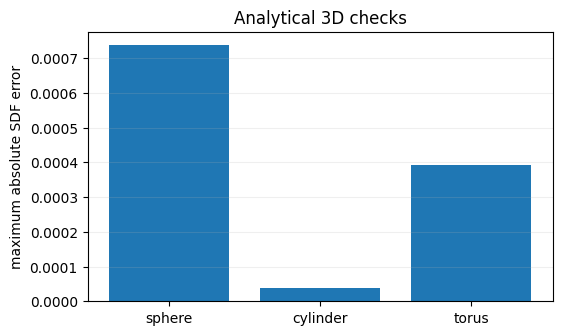

In [9]:
def capped_cylinder_sdf(points, radius, height):
    q = np.column_stack((np.linalg.norm(points[:, :2], axis=1) - radius, np.abs(points[:, 2]) - height / 2))
    return np.linalg.norm(np.maximum(q, 0), axis=1) + np.minimum(np.maximum(q[:, 0], q[:, 1]), 0)


test_rng = np.random.default_rng(23)
test_points = test_rng.uniform(-0.95, 0.95, size=(30000, 3))
solid_models = {
    "sphere": (lambda p: np.linalg.norm(p, axis=1) - 0.65, 0.002),
    "cylinder": (lambda p: capped_cylinder_sdf(p, 0.50, 1.20), 0.0002),
    "torus": (lambda p: np.linalg.norm(np.column_stack((np.linalg.norm(p[:, :2], axis=1) - 0.58, p[:, 2])), axis=1) - 0.20, 0.001),
}

solid_results = []
for name, (exact_sdf, tolerance) in solid_models.items():
    test_mesh = trimesh.load(MODEL_DIR / f"{name}.obj", force="mesh", process=True)
    measured, _, _ = gpy.signed_distance(test_points, test_mesh.vertices, test_mesh.faces)
    exact = exact_sdf(test_points)
    error = np.abs(measured - exact)
    result = {
        "model": name,
        "mean_error": float(error.mean()),
        "p95_error": float(np.quantile(error, 0.95)),
        "max_error": float(error.max()),
        "sign_agreement": float(np.mean(np.signbit(measured) == np.signbit(exact))),
    }
    solid_results.append(result)
    assert result["max_error"] < tolerance
    assert result["sign_agreement"] > 0.999

for result in solid_results:
    print(f"{result['model']:8s} mean={result['mean_error']:.3e}  p95={result['p95_error']:.3e}  max={result['max_error']:.3e}  sign={result['sign_agreement']:.5f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar([result["model"] for result in solid_results], [result["max_error"] for result in solid_results])
ax.set(ylabel="maximum absolute SDF error", title="Analytical 3D checks")
ax.grid(axis="y", alpha=0.2)
plt.show()

### Model topology checks

The suite ranges from genus 0 to genus 2. Genus is recovered from the Euler characteristic of each connected, watertight, orientable surface,

$$
g=\frac{2-\chi}{2}.
$$

The supplied bunny is open, so the same boundary-capping step used above is applied before its genus is evaluated.

In [10]:
expected_genus = {
    "sphere": 0,
    "cylinder": 0,
    "torus": 1,
    "double_torus": 2,
    "bunny": 0,
}

topology_results = []
for name, expected in expected_genus.items():
    raw_mesh = trimesh.load(MODEL_DIR / f"{name}.obj", force="mesh", process=True)
    checked_mesh, repaired = close_mesh(raw_mesh)
    components = checked_mesh.split(only_watertight=False)
    actual = int((2 - checked_mesh.euler_number) // 2)
    result = {
        "model": name,
        "watertight": checked_mesh.is_watertight,
        "components": len(components),
        "repaired_loops": len(repaired),
        "euler": checked_mesh.euler_number,
        "genus": actual,
    }
    topology_results.append(result)
    assert result["watertight"]
    assert result["components"] == 1
    assert result["genus"] == expected

print(f"{'model':13s} {'closed':>7s} {'parts':>7s} {'caps':>6s} {'chi':>5s} {'genus':>7s}")
for result in topology_results:
    print(f"{result['model']:13s} {str(result['watertight']):>7s} {result['components']:7d} {result['repaired_loops']:6d} {result['euler']:5d} {result['genus']:7d}")

model          closed   parts   caps   chi   genus
sphere           True       1      0     2       0
cylinder         True       1      0     2       0
torus            True       1      0     0       1
double_torus     True       1      0    -2       2
bunny            True       1      4     2       0


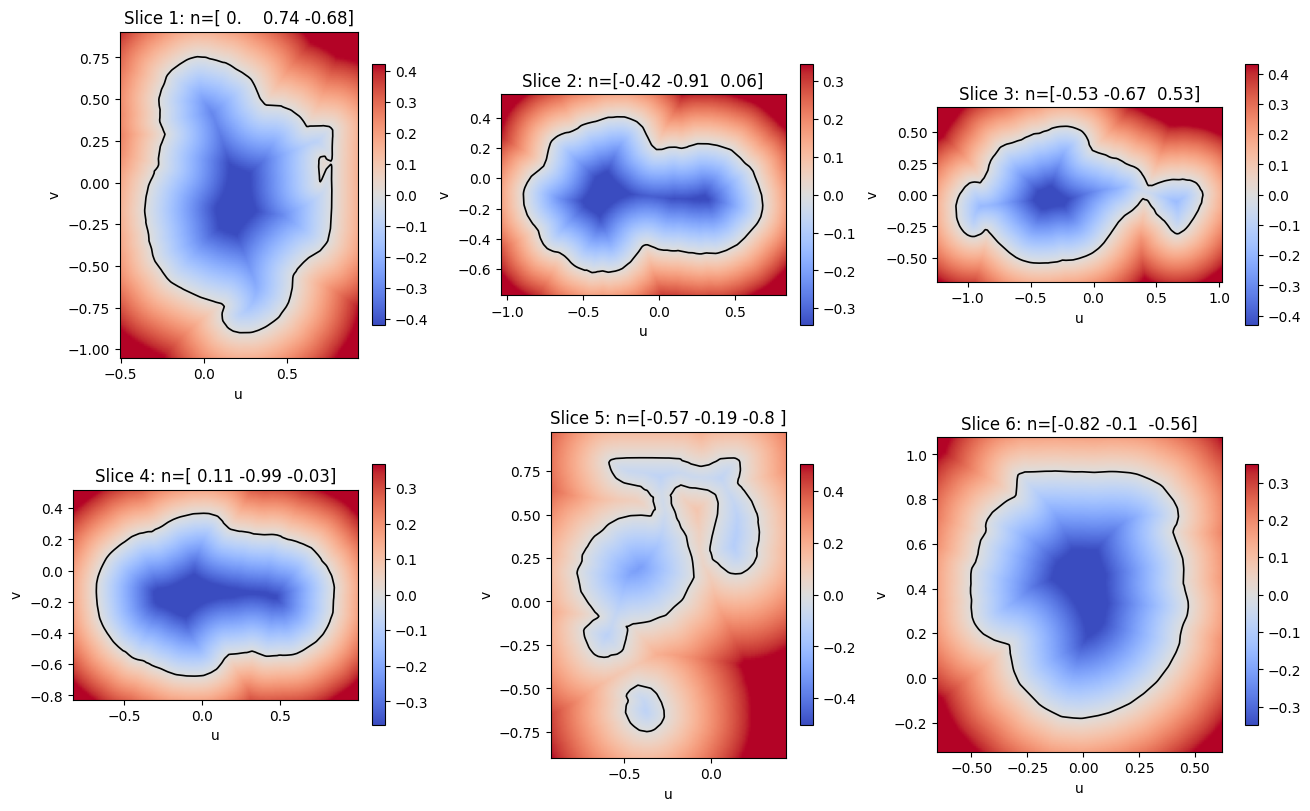

In [11]:
map_resolution = 160
columns = 3
rows = int(np.ceil(N_SLICES / columns))
fig, axes = plt.subplots(rows, columns, figsize=(13, 4 * rows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for plane_id, section in enumerate(sections):
    frame = plane_frame(section["normal"])
    loops2d = [(loop - section["origin"]) @ frame for loop in section["loops"]]
    contour_points = np.vstack(loops2d)
    lower = contour_points.min(axis=0) - 0.15
    upper = contour_points.max(axis=0) + 0.15
    u = np.linspace(lower[0], upper[0], map_resolution)
    v = np.linspace(lower[1], upper[1], map_resolution)
    uv = np.stack(np.meshgrid(u, v, indexing="xy"), axis=-1)
    query = section["origin"] + uv.reshape(-1, 2) @ frame.T
    sdf_map = signed_in_plane_distance(query, section).reshape(map_resolution, map_resolution)

    ax = axes[plane_id]
    limit = np.quantile(np.abs(sdf_map), 0.95)
    image = ax.imshow(sdf_map, origin="lower", extent=[lower[0], upper[0], lower[1], upper[1]], cmap="coolwarm", vmin=-limit, vmax=limit)
    ax.contour(u, v, sdf_map, levels=[0], colors="black", linewidths=1.2)
    ax.set_title(f"Slice {plane_id + 1}: n={section['normal'].round(2)}")
    ax.set_xlabel("u")
    ax.set_ylabel("v")
    ax.set_aspect("equal")
    fig.colorbar(image, ax=ax, shrink=0.8)

for ax in axes[N_SLICES:]:
    ax.set_visible(False)

plt.show()

Slice 1: max excess=-3.617e-09, violations=0/25600


Slice 2: max excess=-1.464e-11, violations=0/25600


Slice 3: max excess=-2.349e-10, violations=0/25600


Slice 4: max excess=-8.098e-11, violations=0/25600


Slice 5: max excess=-2.897e-09, violations=0/25600


Slice 6: max excess=-3.091e-10, violations=0/25600


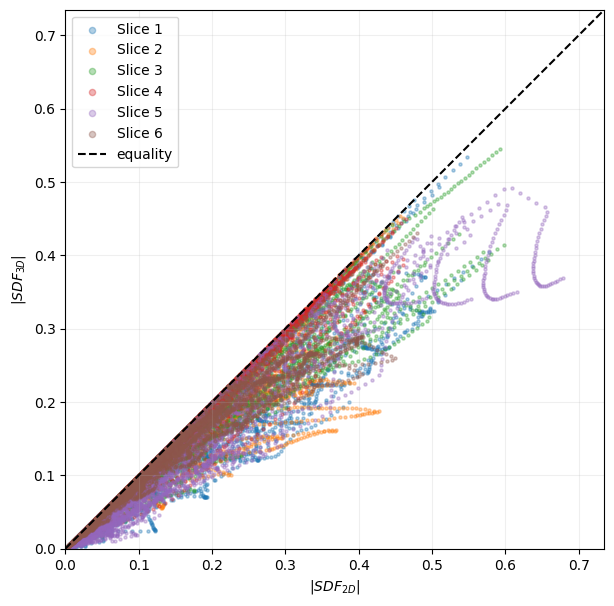

Checked 153,600 plane points; max excess=-1.464e-11


In [12]:
comparison = []
tolerance = 1e-5

for plane_id, section in enumerate(sections):
    frame = plane_frame(section["normal"])
    loops2d = [(loop - section["origin"]) @ frame for loop in section["loops"]]
    contour_points = np.vstack(loops2d)
    lower = contour_points.min(axis=0) - 0.15
    upper = contour_points.max(axis=0) + 0.15
    u = np.linspace(lower[0], upper[0], map_resolution)
    v = np.linspace(lower[1], upper[1], map_resolution)
    uv = np.stack(np.meshgrid(u, v, indexing="xy"), axis=-1)
    query = section["origin"] + uv.reshape(-1, 2) @ frame.T
    sdf2 = signed_in_plane_distance(query, section)
    sdf3, _, _ = gpy.signed_distance(query, mesh.vertices, mesh.faces)
    excess = np.abs(sdf3) - np.abs(sdf2)
    comparison.append((np.abs(sdf2), np.abs(sdf3), excess))
    print(f"Slice {plane_id + 1}: max excess={excess.max():.3e}, violations={np.count_nonzero(excess > tolerance)}/{len(excess)}")

fig, ax = plt.subplots(figsize=(7, 7))
for plane_id, (abs_sdf2, abs_sdf3, _) in enumerate(comparison):
    ax.scatter(abs_sdf2[::8], abs_sdf3[::8], s=5, alpha=0.35, label=f"Slice {plane_id + 1}")
limit = max(values.max() for pair in comparison for values in pair[:2])
ax.plot([0, limit], [0, limit], "k--", linewidth=1.5, label="equality")
ax.set(xlabel=r"$|SDF_{2D}|$", ylabel=r"$|SDF_{3D}|$", xlim=(0, limit), ylim=(0, limit), aspect="equal")
ax.legend(markerscale=2)
ax.grid(alpha=0.2)
plt.show()

max_excess = max(excess.max() for _, _, excess in comparison)
assert max_excess <= tolerance
print(f"Checked {sum(len(excess) for _, _, excess in comparison):,} plane points; max excess={max_excess:.3e}")

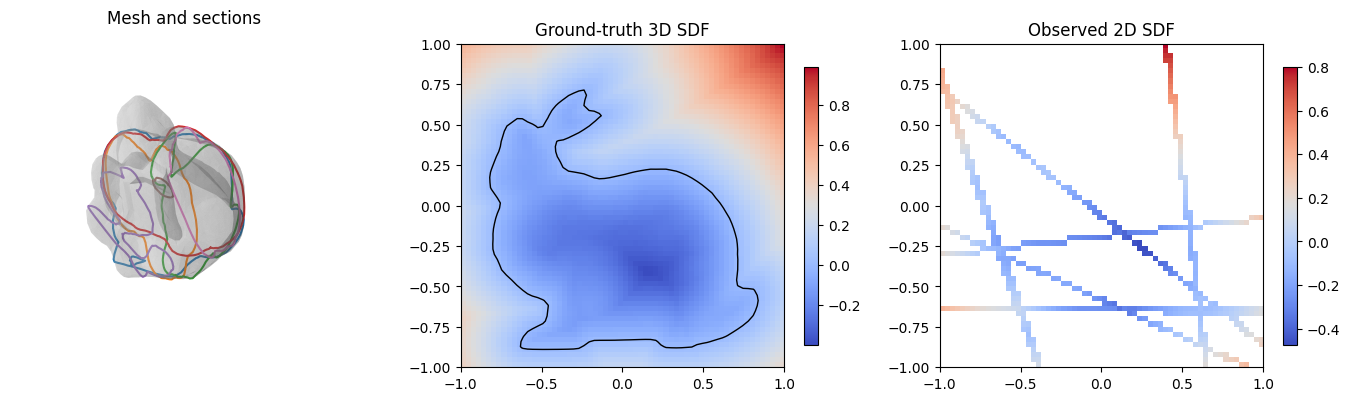

In [13]:
middle = GRID_SIZE // 2
fig = plt.figure(figsize=(14, 4))

ax = fig.add_subplot(1, 3, 1, projection="3d")
ax.plot_trisurf(*mesh.vertices.T, triangles=mesh.faces, color="#b8b8b8", alpha=0.25, linewidth=0)
for section in sections:
    for loop in section["loops"]:
        ax.plot(*loop.T, linewidth=1.5)
ax.set_box_aspect((1, 1, 1))
ax.set_title("Mesh and sections")
ax.set_axis_off()

ax = fig.add_subplot(1, 3, 2)
image = ax.imshow(sdf3d[:, :, middle].T, origin="lower", extent=[GRID_MIN, GRID_MAX] * 2, cmap="coolwarm")
ax.contour(axis, axis, sdf3d[:, :, middle].T, levels=[0], colors="black", linewidths=1)
ax.set_title("Ground-truth 3D SDF")
fig.colorbar(image, ax=ax, shrink=0.8)

ax = fig.add_subplot(1, 3, 3)
shown = np.where(observed_mask[:, :, middle], observed_sdf2d[:, :, middle], np.nan)
image = ax.imshow(shown.T, origin="lower", extent=[GRID_MIN, GRID_MAX] * 2, cmap="coolwarm")
ax.set_title("Observed 2D SDF")
fig.colorbar(image, ax=ax, shrink=0.8)

fig.tight_layout()
plt.show()